# MDR-TS v5.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v5.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**
Using ElasticNet regression for better generalization.

For other info see `MDR-TS-v1.0`

## 0. Imports

In [2]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# Sklearn
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Utils
from tqdm.auto import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [3]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [4]:
# Project paths
VERSION = "v5"
SUBVERSION = "v5.3"
RUN_NAME = "mdr_ts_v5_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v5/v5.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [5]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_all/train_derived_all.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_all/val_derived_all.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_all/test_derived_all.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv
train: dropped columns ['slope', 'elev']

train: shape=(15904, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(3408, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(3408, 352)
test: columns=352


In [6]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns))

Common columns across splits: 352

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14', 'A_d_G_API_kobs30', 'A_grad_G_API_kobs7', 'A_grad_G_API_kobs14', 'A_grad_G_API_kobs30', 'A_pct_G_API', 'V_rollstd_G_API_kobs7', 'V_rollrng_G_API_kobs7', 'V_rollcv_G_API_kobs7', 'V_rollmean_G_API_kobs7', 'V_rollmin_G_API_kobs7', 'V_rollmax_G_API_kobs7', 'V_ema_G_API_kobs7', 'V_rollstd_G_API_kobs14', 'V_rollrng_G_API_kobs14', 'V_rollcv_G_API_kobs14', 'V_rollmean_G_API_kobs14', 'V_rollmin_G_API_kobs14', 'V_rollmax_G_API_kobs14', 'V_ema_G_API_kobs14', 'V_rollstd_G_API_kobs30', 'V_rollrng_G_API_kobs30', 'V_rollcv_G_API_kobs30', 'V_rollmean_G_API_kobs30', 'V_roll

## 4. Data Sanity Checks

In [7]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = ['precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8',
                's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY',
                'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio',
                'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d',
                'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1',
                'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7',
                'A_d_G_API_kobs14', 'A_d_G_API_kobs30', 'A_grad_G_API_kobs7',
                'A_grad_G_API_kobs14', 'A_grad_G_API_kobs30', 'A_pct_G_API',
                'V_rollstd_G_API_kobs7', 'V_rollrng_G_API_kobs7',
                'V_rollcv_G_API_kobs7', 'V_rollmean_G_API_kobs7',
                'V_rollmin_G_API_kobs7', 'V_rollmax_G_API_kobs7',
                'V_ema_G_API_kobs7', 'V_rollstd_G_API_kobs14',
                'V_rollrng_G_API_kobs14', 'V_rollcv_G_API_kobs14',
                'V_rollmean_G_API_kobs14', 'V_rollmin_G_API_kobs14',
                'V_rollmax_G_API_kobs14', 'V_ema_G_API_kobs14',
                'V_rollstd_G_API_kobs30', 'V_rollrng_G_API_kobs30',
                'V_rollcv_G_API_kobs30', 'V_rollmean_G_API_kobs30',
                'V_rollmin_G_API_kobs30', 'V_rollmax_G_API_kobs30',
                'V_ema_G_API_kobs30', 'C_lag_G_API_kobs1', 'C_lag_G_API_kobs2',
                'C_lag_G_API_kobs5', 'C_lag_G_API_kobs6', 'C_lag_G_API_kobs12',
                'C_lag_G_API_kobs30', 'C_smm_G_API_alpha0.85_n5', 'A_d_F_NDMI_kobs1',
                'A_d_F_NDMI_kobs2', 'A_d_F_NDMI_kobs5', 'A_d_F_NDMI_kobs7',
                'A_d_F_NDMI_kobs14', 'A_d_F_NDMI_kobs30', 'A_grad_F_NDMI_kobs7',
                'A_grad_F_NDMI_kobs14', 'A_grad_F_NDMI_kobs30', 'A_pct_F_NDMI',
                'V_rollstd_F_NDMI_kobs7', 'V_rollrng_F_NDMI_kobs7',
                'V_rollcv_F_NDMI_kobs7', 'V_rollmean_F_NDMI_kobs7',
                'V_rollmin_F_NDMI_kobs7', 'V_rollmax_F_NDMI_kobs7',
                'V_ema_F_NDMI_kobs7', 'V_rollstd_F_NDMI_kobs14',
                'V_rollrng_F_NDMI_kobs14', 'V_rollcv_F_NDMI_kobs14',
                'V_rollmean_F_NDMI_kobs14', 'V_rollmin_F_NDMI_kobs14',
                'V_rollmax_F_NDMI_kobs14', 'V_ema_F_NDMI_kobs14',
                'V_rollstd_F_NDMI_kobs30', 'V_rollrng_F_NDMI_kobs30',
                'V_rollcv_F_NDMI_kobs30', 'V_rollmean_F_NDMI_kobs30',
                'V_rollmin_F_NDMI_kobs30', 'V_rollmax_F_NDMI_kobs30',
                'V_ema_F_NDMI_kobs30', 'C_lag_F_NDMI_kobs1', 'C_lag_F_NDMI_kobs2',
                'C_lag_F_NDMI_kobs5', 'C_lag_F_NDMI_kobs6', 'C_lag_F_NDMI_kobs12',
                'C_lag_F_NDMI_kobs30', 'C_smm_F_NDMI_alpha0.85_n5', 'A_d_E_SAR_ratio_kobs1',
                'A_d_E_SAR_ratio_kobs2', 'A_d_E_SAR_ratio_kobs5', 'A_d_E_SAR_ratio_kobs7',
                'A_d_E_SAR_ratio_kobs14', 'A_d_E_SAR_ratio_kobs30', 'A_grad_E_SAR_ratio_kobs7',
                'A_grad_E_SAR_ratio_kobs14', 'A_grad_E_SAR_ratio_kobs30', 'A_pct_E_SAR_ratio',
                'V_rollstd_E_SAR_ratio_kobs7', 'V_rollrng_E_SAR_ratio_kobs7',
                'V_rollcv_E_SAR_ratio_kobs7', 'V_rollmean_E_SAR_ratio_kobs7',
                'V_rollmin_E_SAR_ratio_kobs7', 'V_rollmax_E_SAR_ratio_kobs7',
                'V_ema_E_SAR_ratio_kobs7', 'V_rollstd_E_SAR_ratio_kobs14',
                'V_rollrng_E_SAR_ratio_kobs14', 'V_rollcv_E_SAR_ratio_kobs14',
                'V_rollmean_E_SAR_ratio_kobs14', 'V_rollmin_E_SAR_ratio_kobs14',
                'V_rollmax_E_SAR_ratio_kobs14', 'V_ema_E_SAR_ratio_kobs14', 'V_rollstd_E_SAR_ratio_kobs30',
                'V_rollrng_E_SAR_ratio_kobs30', 'V_rollcv_E_SAR_ratio_kobs30', 'V_rollmean_E_SAR_ratio_kobs30',
                'V_rollmin_E_SAR_ratio_kobs30', 'V_rollmax_E_SAR_ratio_kobs30', 'V_ema_E_SAR_ratio_kobs30',
                'C_lag_E_SAR_ratio_kobs1', 'C_lag_E_SAR_ratio_kobs2', 'C_lag_E_SAR_ratio_kobs5',
                'C_lag_E_SAR_ratio_kobs6', 'C_lag_E_SAR_ratio_kobs12', 'C_lag_E_SAR_ratio_kobs30',
                'C_smm_E_SAR_ratio_alpha0.85_n5', 'A_d_LST_modis_kobs1', 'A_d_LST_modis_kobs2',
                'A_d_LST_modis_kobs5', 'A_d_LST_modis_kobs7', 'A_d_LST_modis_kobs14', 'A_d_LST_modis_kobs30',
                'A_grad_LST_modis_kobs7', 'A_grad_LST_modis_kobs14', 'A_grad_LST_modis_kobs30',
                'A_pct_LST_modis', 'V_rollstd_LST_modis_kobs7', 'V_rollrng_LST_modis_kobs7',
                'V_rollcv_LST_modis_kobs7', 'V_rollmean_LST_modis_kobs7', 'V_rollmin_LST_modis_kobs7',
                'V_rollmax_LST_modis_kobs7', 'V_ema_LST_modis_kobs7', 'V_rollstd_LST_modis_kobs14',
                'V_rollrng_LST_modis_kobs14', 'V_rollcv_LST_modis_kobs14', 'V_rollmean_LST_modis_kobs14',
                'V_rollmin_LST_modis_kobs14', 'V_rollmax_LST_modis_kobs14', 'V_ema_LST_modis_kobs14',
                'V_rollstd_LST_modis_kobs30', 'V_rollrng_LST_modis_kobs30', 'V_rollcv_LST_modis_kobs30',
                'V_rollmean_LST_modis_kobs30', 'V_rollmin_LST_modis_kobs30', 'V_rollmax_LST_modis_kobs30',
                'V_ema_LST_modis_kobs30', 'C_lag_LST_modis_kobs1', 'C_lag_LST_modis_kobs2',
                'C_lag_LST_modis_kobs5', 'C_lag_LST_modis_kobs6', 'C_lag_LST_modis_kobs12',
                'C_lag_LST_modis_kobs30', 'C_smm_LST_modis_alpha0.85_n5', 'A_d_F_NDVI_kobs1',
                'A_d_F_NDVI_kobs2', 'A_d_F_NDVI_kobs5', 'A_d_F_NDVI_kobs7', 'A_d_F_NDVI_kobs14',
                'A_d_F_NDVI_kobs30', 'A_grad_F_NDVI_kobs7', 'A_grad_F_NDVI_kobs14',
                'A_grad_F_NDVI_kobs30', 'A_pct_F_NDVI', 'V_rollstd_F_NDVI_kobs7',
                'V_rollrng_F_NDVI_kobs7', 'V_rollcv_F_NDVI_kobs7', 'V_rollmean_F_NDVI_kobs7',
                'V_rollmin_F_NDVI_kobs7', 'V_rollmax_F_NDVI_kobs7', 'V_ema_F_NDVI_kobs7',
                'V_rollstd_F_NDVI_kobs14', 'V_rollrng_F_NDVI_kobs14', 'V_rollcv_F_NDVI_kobs14',
                'V_rollmean_F_NDVI_kobs14', 'V_rollmin_F_NDVI_kobs14', 'V_rollmax_F_NDVI_kobs14',
                'V_ema_F_NDVI_kobs14', 'V_rollstd_F_NDVI_kobs30', 'V_rollrng_F_NDVI_kobs30',
                'V_rollcv_F_NDVI_kobs30', 'V_rollmean_F_NDVI_kobs30', 'V_rollmin_F_NDVI_kobs30',
                'V_rollmax_F_NDVI_kobs30', 'V_ema_F_NDVI_kobs30', 'C_lag_F_NDVI_kobs1',
                'C_lag_F_NDVI_kobs2', 'C_lag_F_NDVI_kobs5', 'C_lag_F_NDVI_kobs6', 'C_lag_F_NDVI_kobs12',
                'C_lag_F_NDVI_kobs30', 'C_smm_F_NDVI_alpha0.85_n5', 'A_d_E_SAR_diff_kobs1',
                'A_d_E_SAR_diff_kobs2', 'A_d_E_SAR_diff_kobs5', 'A_d_E_SAR_diff_kobs7',
                'A_d_E_SAR_diff_kobs14', 'A_d_E_SAR_diff_kobs30', 'A_grad_E_SAR_diff_kobs7',
                'A_grad_E_SAR_diff_kobs14', 'A_grad_E_SAR_diff_kobs30', 'A_pct_E_SAR_diff',
                'V_rollstd_E_SAR_diff_kobs7', 'V_rollrng_E_SAR_diff_kobs7', 'V_rollcv_E_SAR_diff_kobs7',
                'V_rollmean_E_SAR_diff_kobs7', 'V_rollmin_E_SAR_diff_kobs7', 'V_rollmax_E_SAR_diff_kobs7',
                'V_ema_E_SAR_diff_kobs7', 'V_rollstd_E_SAR_diff_kobs14', 'V_rollrng_E_SAR_diff_kobs14',
                'V_rollcv_E_SAR_diff_kobs14', 'V_rollmean_E_SAR_diff_kobs14', 'V_rollmin_E_SAR_diff_kobs14',
                'V_rollmax_E_SAR_diff_kobs14', 'V_ema_E_SAR_diff_kobs14', 'V_rollstd_E_SAR_diff_kobs30',
                'V_rollrng_E_SAR_diff_kobs30', 'V_rollcv_E_SAR_diff_kobs30', 'V_rollmean_E_SAR_diff_kobs30',
                'V_rollmin_E_SAR_diff_kobs30', 'V_rollmax_E_SAR_diff_kobs30', 'V_ema_E_SAR_diff_kobs30',
                'C_lag_E_SAR_diff_kobs1', 'C_lag_E_SAR_diff_kobs2', 'C_lag_E_SAR_diff_kobs5', 'C_lag_E_SAR_diff_kobs6',
                'C_lag_E_SAR_diff_kobs12', 'C_lag_E_SAR_diff_kobs30', 'C_smm_E_SAR_diff_alpha0.85_n5', 'A_d_s2_b11_kobs1',
                'A_d_s2_b11_kobs2', 'A_d_s2_b11_kobs5', 'A_d_s2_b11_kobs7', 'A_d_s2_b11_kobs14',
                'A_d_s2_b11_kobs30', 'A_grad_s2_b11_kobs7', 'A_grad_s2_b11_kobs14', 'A_grad_s2_b11_kobs30',
                'A_pct_s2_b11', 'V_rollstd_s2_b11_kobs7', 'V_rollrng_s2_b11_kobs7', 'V_rollcv_s2_b11_kobs7',
                'V_rollmean_s2_b11_kobs7', 'V_rollmin_s2_b11_kobs7', 'V_rollmax_s2_b11_kobs7', 'V_ema_s2_b11_kobs7',
                'V_rollstd_s2_b11_kobs14', 'V_rollrng_s2_b11_kobs14', 'V_rollcv_s2_b11_kobs14',
                'V_rollmean_s2_b11_kobs14', 'V_rollmin_s2_b11_kobs14', 'V_rollmax_s2_b11_kobs14', 'V_ema_s2_b11_kobs14',
                'V_rollstd_s2_b11_kobs30', 'V_rollrng_s2_b11_kobs30', 'V_rollcv_s2_b11_kobs30',
                'V_rollmean_s2_b11_kobs30', 'V_rollmin_s2_b11_kobs30', 'V_rollmax_s2_b11_kobs30',
                'V_ema_s2_b11_kobs30', 'C_lag_s2_b11_kobs1', 'C_lag_s2_b11_kobs2', 'C_lag_s2_b11_kobs5',
                'C_lag_s2_b11_kobs6', 'C_lag_s2_b11_kobs12', 'C_lag_s2_b11_kobs30', 'C_smm_s2_b11_alpha0.85_n5',
                'A_d_s2_b12_kobs1', 'A_d_s2_b12_kobs2', 'A_d_s2_b12_kobs5', 'A_d_s2_b12_kobs7', 'A_d_s2_b12_kobs14',
                'A_d_s2_b12_kobs30', 'A_grad_s2_b12_kobs7', 'A_grad_s2_b12_kobs14', 'A_grad_s2_b12_kobs30',
                'A_pct_s2_b12', 'V_rollstd_s2_b12_kobs7', 'V_rollrng_s2_b12_kobs7', 'V_rollcv_s2_b12_kobs7',
                'V_rollmean_s2_b12_kobs7', 'V_rollmin_s2_b12_kobs7', 'V_rollmax_s2_b12_kobs7',
                'V_ema_s2_b12_kobs7', 'V_rollstd_s2_b12_kobs14', 'V_rollrng_s2_b12_kobs14',
                'V_rollcv_s2_b12_kobs14', 'V_rollmean_s2_b12_kobs14', 'V_rollmin_s2_b12_kobs14',
                'V_rollmax_s2_b12_kobs14', 'V_ema_s2_b12_kobs14', 'V_rollstd_s2_b12_kobs30',
                'V_rollrng_s2_b12_kobs30', 'V_rollcv_s2_b12_kobs30', 'V_rollmean_s2_b12_kobs30',
                'V_rollmin_s2_b12_kobs30', 'V_rollmax_s2_b12_kobs30', 'V_ema_s2_b12_kobs30',
                'C_lag_s2_b12_kobs1', 'C_lag_s2_b12_kobs2', 'C_lag_s2_b12_kobs5', 'C_lag_s2_b12_kobs6',
                'C_lag_s2_b12_kobs12', 'C_lag_s2_b12_kobs30', 'C_smm_s2_b12_alpha0.85_n5', 'E_dVV_1',
                'E_rough_s1_vv_kobs7', 'E_rough_s1_vh_kobs7', 'E_rough_s1_vv_kobs14', 'E_rough_s1_vh_kobs14',
                'I_ts_spike_s1_vv', 'H_corr_E_SAR_ratio__F_NDMI_kobs7', 'H_corr_E_SAR_ratio__F_NDMI_kobs14',
                'H_corr_LST_modis__F_NDMI_kobs7', 'H_corr_LST_modis__F_NDMI_kobs14', 'D_sa_F_NDMI', 'D_z_F_NDMI',
                'D_sa_E_SAR_ratio', 'D_z_E_SAR_ratio', 'D_sa_LST_modis', 'D_z_LST_modis', 'D_fft_dom_F_NDMI_kobs30',
                'D_fft_ent_F_NDMI_kobs30', 'D_fft_dom_E_SAR_ratio_kobs30', 'D_fft_ent_E_SAR_ratio_kobs30',
                'D_fft_dom_LST_modis_kobs30', 'D_fft_ent_LST_modis_kobs30', 'G_DSLR_isnan']

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 347
  Target:   soil_moisture_5cm


In [8]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[OK] station Touchet_WA_824: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [9]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-17 00:00:00
    val   min date: 2021-08-18 00:00:00
  Station Quinault:
    train max date: 2021-09-03 00:00:00
    val   min date: 2021-09-04 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-05-13 00:00:00
    val   min date: 2021-05-14 00:00:00
  Station Spokane:
    train max date: 2021-09-19 00:00:00
    val   min date: 2021-09-20 00:00:00
  Station Touchet_WA_824:
    train max date: 2018-06-07 00:00:00
    val   min date: 2018-06-08 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [10]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-19 00:00:00

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 00:00:00 -- 2023-12-29 00:00:00

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [11]:
FEATURE_COLS_EN = list(FEATURE_COLS)

X_train = train_df[FEATURE_COLS_EN].copy()
X_val   = val_df[FEATURE_COLS_EN].copy()
X_test  = test_df[FEATURE_COLS_EN].copy()

y_train = train_df[TARGET_COL].astype(float).copy()
y_val   = val_df[TARGET_COL].astype(float).copy()
y_test  = test_df[TARGET_COL].astype(float).copy()


def sanitize_for_elasticnet(X, huge_thr=1e12):
    X = X.astype(np.float64, copy=True)
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.mask(np.abs(X) > huge_thr, np.nan)
    return X

X_train_clean = sanitize_for_elasticnet(X_train, huge_thr=1e12)
X_val_clean   = sanitize_for_elasticnet(X_val, huge_thr=1e12)
X_test_clean  = sanitize_for_elasticnet(X_test, huge_thr=1e12)

print("ElasticNet shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_val:  ", X_val.shape,   " y_val:  ", y_val.shape)
print("  X_test: ", X_test.shape,  " y_test: ", y_test.shape)

non_numeric = [c for c in FEATURE_COLS_EN if not pd.api.types.is_numeric_dtype(train_df[c])]
if non_numeric:
    print("[WARN] Non-numeric features found, dropping:", non_numeric)
    FEATURE_COLS_EN = [c for c in FEATURE_COLS_EN if c not in non_numeric]
    X_train = train_df[FEATURE_COLS_EN].copy()
    X_val   = val_df[FEATURE_COLS_EN].copy()
    X_test  = test_df[FEATURE_COLS_EN].copy()

print("Final feature count:", len(FEATURE_COLS_EN))

ElasticNet shapes:
  X_train: (15904, 347)  y_train: (15904,)
  X_val:   (3408, 347)  y_val:   (3408,)
  X_test:  (3408, 347)  y_test:  (3408,)
Final feature count: 347


## 7. Training Loop

### 7.1 Fit Model

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
l1_grid = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]
models = []
rows = []

for l1 in tqdm(l1_grid, desc="ElasticNet l1_ratio sweep"):
    enet = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=l1,
            alphas=np.logspace(-4, 1, 80),
            cv=cv,
            max_iter=20000,
            n_jobs=-1,
            random_state=SEED,
        ))
    ])

    enet.fit(X_train_clean, y_train)

    model = enet.named_steps["model"]

    mse_mean = model.mse_path_.mean(axis=1)   # mean over folds, one value per alpha
    mse_std  = model.mse_path_.std(axis=1)

    best_idx = np.argmin(mse_mean)            # index of best alpha in this CV curve
    best_alpha_from_curve = model.alphas_[best_idx]

    # locate the index of model.alpha_ (the alpha ElasticNetCV actually chose)
    chosen_idx = int(np.where(model.alphas_ == model.alpha_)[0][0])
    chosen_mse_mean = float(mse_mean[chosen_idx])
    chosen_mse_std  = float(mse_std[chosen_idx])


    rows.append({
        "l1_ratio": l1,
        "alpha": float(model.alpha_),
        "chosen_cv_mse_mean": chosen_mse_mean,
        "chosen_cv_mse_std": chosen_mse_std,
        "best_cv_mse_mean": float(mse_mean[best_idx]),
        "best_alpha_curve": float(best_alpha_from_curve),
    })

results_enet_cv = pd.DataFrame(rows)

ElasticNet l1_ratio sweep:   0%|          | 0/7 [00:00<?, ?it/s]

In [14]:
best_row = (
    results_enet_cv
    .sort_values(["chosen_cv_mse_mean", "chosen_cv_mse_std"], ascending=[True, True])
    .iloc[0]
)

best_l1 = float(best_row["l1_ratio"])
print(best_l1)

0.1


### 7.2 Metrics

In [15]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def metrics_block(name, y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    resid = y_true - y_pred
    abs_err = np.abs(resid)

    return {
        "split": name,
        "n": int(len(y_true)),
        "MAE": float(np.mean(abs_err)),
        "RMSE": float(np.sqrt(np.mean(resid**2))),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean_resid": float(np.mean(resid)),
        "bias_abs": float(np.abs(np.mean(resid))),
        "resid_std": float(np.std(resid, ddof=1)) if len(resid) > 1 else 0.0,
        "p90_abs_err": float(np.quantile(abs_err, 0.90)),
        "median_abs_err": float(np.median(abs_err)),
    }

yhat_train = enet.predict(X_train_clean)
yhat_val   = enet.predict(X_val_clean)
yhat_test  = enet.predict(X_test_clean)

results_enet = pd.DataFrame([
    metrics_block("train", y_train.values, yhat_train),
    metrics_block("val",   y_val.values,   yhat_val),
    metrics_block("test",  y_test.values,  yhat_test),
])

results_enet

,split,n,MAE,RMSE,R2,bias_mean_resid,bias_abs,resid_std,p90_abs_err,median_abs_err
0,train,15904,0.042621,0.053616,0.722787,5.718654e-17,5.718654e-17,0.053617,0.087031,0.036355
1,val,3408,0.047666,0.060332,0.684616,4.213525e-03,4.213525e-03,0.060194,0.098119,0.039537
2,test,3408,0.049490,0.061387,0.564117,8.470942e-03,8.470942e-03,0.060808,0.097682,0.043455


## 7.2.1 Re-fitting the Best Model (All features)

In [18]:
best_enet = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=best_l1,
        alphas=np.logspace(-4, 1, 80),
        cv=cv,
        max_iter=20000,
        n_jobs=-1,
        random_state=SEED,
    ))
])

best_enet.fit(X_train_clean, y_train)

yhat_train_best = enet.predict(X_train_clean)
yhat_val_best   = enet.predict(X_val_clean)
yhat_test_best  = enet.predict(X_test_clean)

results_enet_best = pd.DataFrame([
    metrics_block("train", y_train.values, yhat_train_best),
    metrics_block("val",   y_val.values,   yhat_val_best),
    metrics_block("test",  y_test.values,  yhat_test_best),
])

results_enet_best

,split,n,MAE,RMSE,R2,bias_mean_resid,bias_abs,resid_std,p90_abs_err,median_abs_err
0,train,15904,0.042621,0.053616,0.722787,5.718654e-17,5.718654e-17,0.053617,0.087031,0.036355
1,val,3408,0.047666,0.060332,0.684616,4.213525e-03,4.213525e-03,0.060194,0.098119,0.039537
2,test,3408,0.049490,0.061387,0.564117,8.470942e-03,8.470942e-03,0.060808,0.097682,0.043455


### 7.3 Feature Based Persistence Baseline

In [20]:
CANDIDATES = [c for c in FEATURE_COLS_EN if ("lag" in c.lower() and TARGET_COL in c) or (c.lower().endswith("soil_moisture_5cm_lag1"))]
print("Lag candidates:", CANDIDATES[:10])

if CANDIDATES:
    lag_col = CANDIDATES[0]
    base_val  = val_df[lag_col].astype(float).values
    base_test = test_df[lag_col].astype(float).values

    # Drop NaNs to compute fair R²
    m_val = ~np.isnan(base_val)
    m_test = ~np.isnan(base_test)

    print("Persistence via feature:", lag_col)
    print("Val R2:", r2_score(y_val.values[m_val], base_val[m_val]))
    print("Test R2:", r2_score(y_test.values[m_test], base_test[m_test]))
else:
    print("No lag feature found in FEATURE_COLS_EN. Skipping feature-based persistence baseline.")

Lag candidates: []
No lag feature found in FEATURE_COLS_EN. Skipping feature-based persistence baseline.


### 7.5 Surviving Features Analysis

In [21]:
enet = best_enet.named_steps["model"]

coefs = enet.coef_
coef_s = pd.Series(coefs, index=FEATURE_COLS_EN)

nonzero = coef_s[coef_s.abs() > 1e-12].sort_values(key=np.abs, ascending=False)
print("Non-zero features:", len(nonzero), "/", len(coef_s))

display(nonzero.head(25))

zero = coef_s[coef_s.abs() <= 1e-12]
print("Zeroed features:", len(zero))

Non-zero features: 238 / 347


E_SAR_ratio                     -0.191123
D_sa_E_SAR_ratio                 0.177492
V_ema_LST_modis_kobs30          -0.160286
V_ema_E_SAR_ratio_kobs30         0.111728
V_ema_E_SAR_ratio_kobs14        -0.093668
D_z_E_SAR_ratio                  0.086874
D_z_F_NDMI                       0.065847
V_rollmean_F_NDMI_kobs30         0.060279
V_rollmax_s2_b12_kobs30         -0.058884
V_ema_F_NDMI_kobs30             -0.058072
V_rollmin_s2_b12_kobs30         -0.054957
V_rollmean_E_SAR_ratio_kobs30   -0.053885
V_rollcv_LST_modis_kobs30       -0.051364
V_rollmin_F_NDMI_kobs30         -0.050787
V_rollstd_LST_modis_kobs30       0.049617
s1_vh                           -0.045532
V_rollstd_LST_modis_kobs14       0.044034
V_ema_G_API_kobs30              -0.043125
V_rollcv_LST_modis_kobs14       -0.041497
V_rollmax_s2_b11_kobs30          0.039962
V_ema_E_SAR_ratio_kobs7         -0.038987
V_rollmean_s2_b12_kobs30         0.038005
C_lag_F_NDMI_kobs30             -0.037982
V_rollmax_F_NDVI_kobs30          0

Zeroed features: 109


### 7.6 Refit on Surviving Features

In [32]:
from sklearn.linear_model import ElasticNet

TOP_K = min(40, len(nonzero))
keep = nonzero.head(TOP_K).index.tolist()
print("Refitting using TOP_K =", TOP_K)

enet_small = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=best_enet.named_steps["model"].alpha_,
        l1_ratio=best_l1,
        max_iter=20000,
        random_state=SEED
    ))
])

enet_small.fit(train_df[keep], y_train)

yhat_train_new = enet_small.predict(train_df[keep])
yhat_val_new   = enet_small.predict(val_df[keep])
yhat_test_new  = enet_small.predict(test_df[keep])

results_enet_best = pd.DataFrame([
    metrics_block("train", y_train.values, yhat_train_new),
    metrics_block("val",   y_val.values,   yhat_val_new),
    metrics_block("test",  y_test.values,  yhat_test_new),
])

results_enet_best

Refitting using TOP_K = 40


,split,n,MAE,RMSE,R2,bias_mean_resid,bias_abs,resid_std,p90_abs_err,median_abs_err
0,train,15904,0.045465,0.057466,0.681546,1.429663e-17,1.429663e-17,0.057467,0.094034,0.037799
1,val,3408,0.046435,0.060286,0.685095,7.259998e-03,7.259998e-03,0.059857,0.099859,0.037137
2,test,3408,0.052034,0.063987,0.526415,8.120091e-03,8.120091e-03,0.063479,0.104016,0.046132


### 7.7 Diagnostics

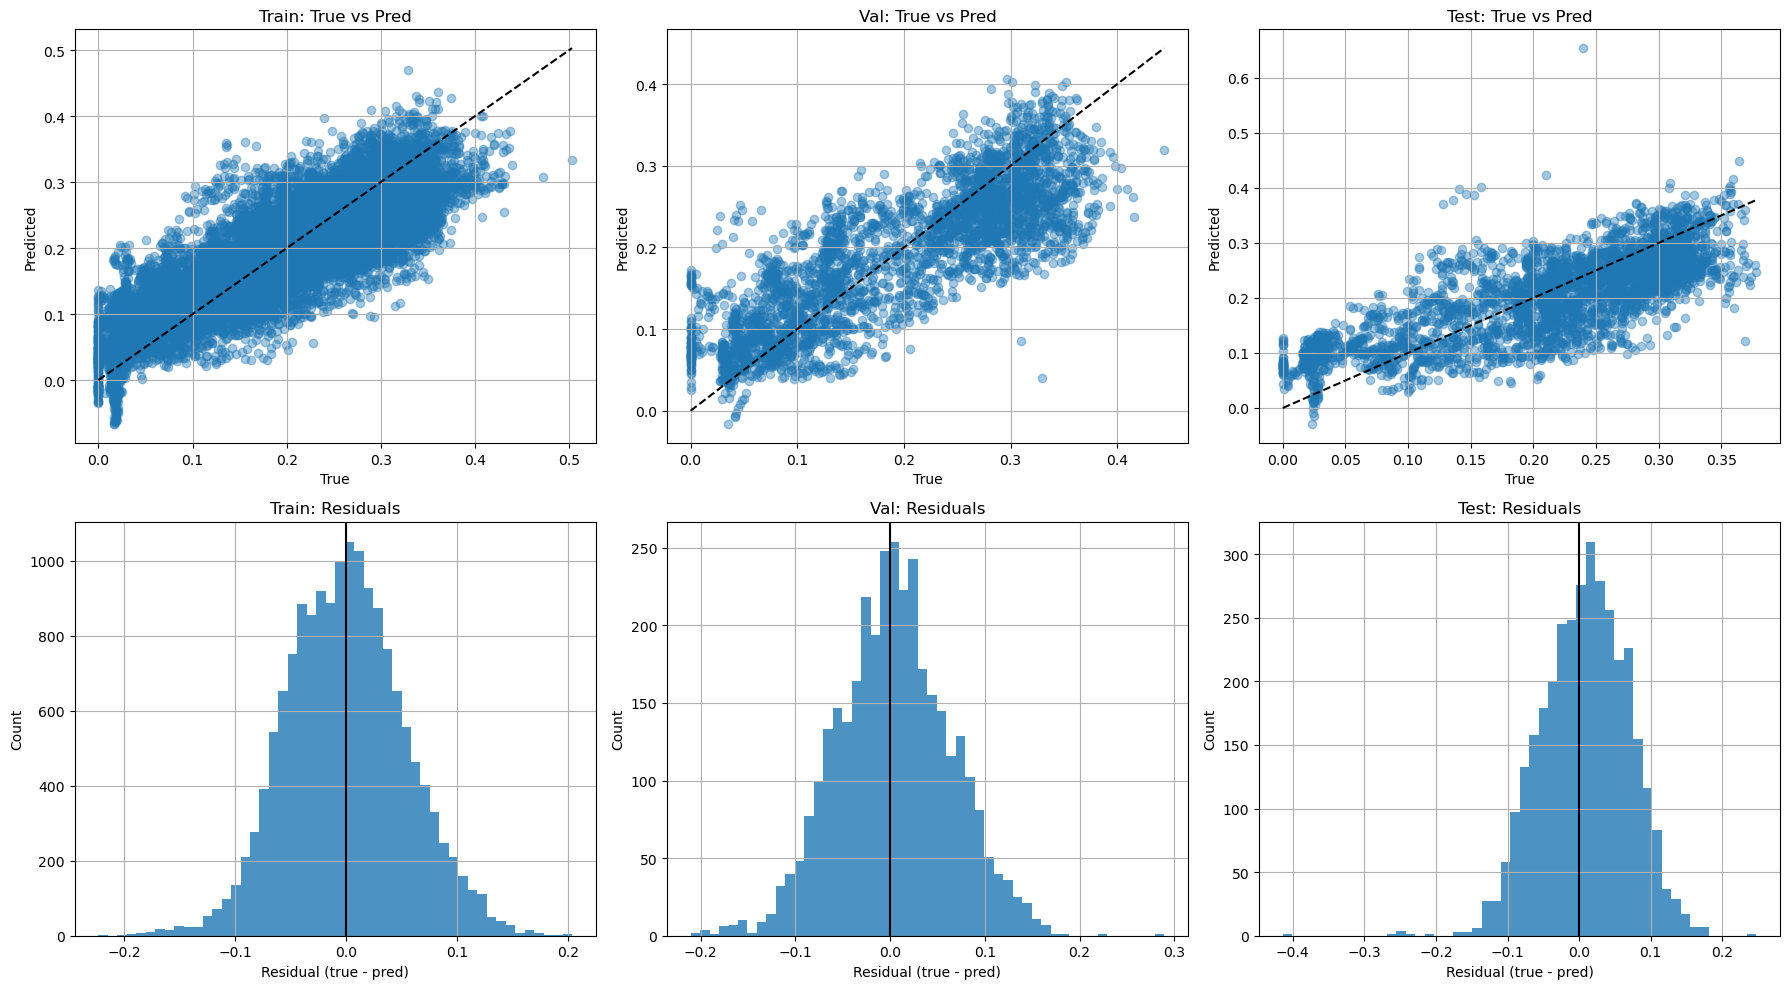

In [33]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

## 8. Evaluation

### 8.1 Test Metrics

In [34]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.04949,0.061387,0.564117,3408


### 8.2 Test Prediction Scatter

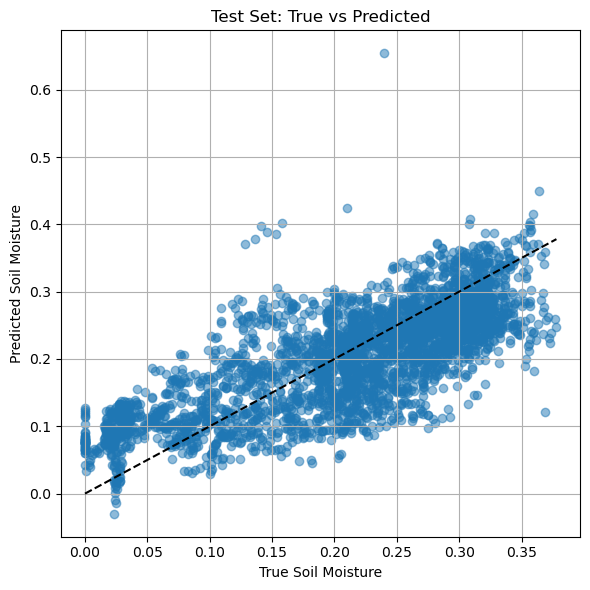

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [36]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val.min()): .6f} to {float(yhat_val.max()): .6f}
TEST range : {float(yhat_test.min()): .6f} to {float(yhat_test.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.004214
TEST residual mean :  0.008471

Prediction ranges
-----------------
VAL  range : -0.016787 to  0.405649
TEST range : -0.029844 to  0.653991



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [37]:
results_idx = results_enet.set_index("split")

gap = {
    "train -> val (MAE)": float(results_idx.loc["val", "MAE"] - results_idx.loc["train", "MAE"]),
    "val -> test (MAE)":  float(results_idx.loc["test", "MAE"] - results_idx.loc["val", "MAE"]),
}
pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.005045
val -> test (MAE),0.001824


In [ ]:
keep

40


---

_Jakob Balkovec_